Andrew Doherty Munro
DATA 30195
Final Project Notebook

Question and Motivation

Background and Literature Review

Data Sources

Results

In [19]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

Load in generic "Parks" shapefile, subset to Cook County and project to Illinois State Plane East CRS:

In [18]:
parks = gpd.read_file(r'data/shapefiles/Parks.shp')

cook_county = parks[(parks['Park_State'] == 'Illinois') & (parks['Park_Count'] == 'Cook County')]
cook_county = cook_county.to_crs(epsg=26971)

Plot to get a sense of coverage:

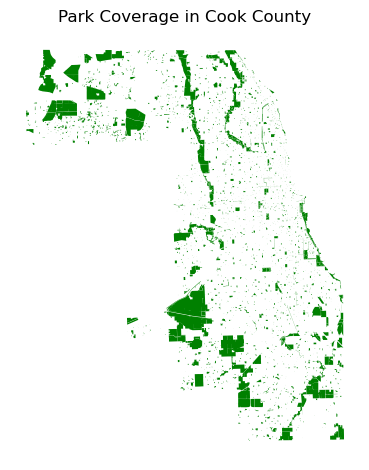

In [23]:
fig, ax = plt.subplots(1, 1)

cook_county.plot(color='green', ax=ax)

ax.set_axis_off()
ax.set_title('Park Coverage in Cook County')

plt.tight_layout()
plt.show()

In [6]:
parks.head()

,ParkID,GISTrkrID,SourceID,Park_Name,Park_Desig,Park_Owner,Park_Local,Park_Manag,Park_Loc_1,Park_Acces,...,Park_Size_,Park_Addre,Park_State,Park_Count,Park_Place,Park_Urban,Park_Zip,Shape_Leng,Shape_Area,geometry
0,3901000-0001,3089,1,Hampton Hills Park,LP,MUNI,City of Akron,MUNI,City of Akron,3,...,317.339342,1285 Bath Rd,Ohio,Summit County,Cuyahoga Falls city,"Akron, OH",44223,5987.262459,1.284227e+06,"POLYGON ((1136229.116 225036.19, 1136234.005 2..."
1,3901000-0002,3089,2,Frank Boulevard Park,LP,MUNI,City of Akron,MUNI,City of Akron,3,...,20.586117,2086 Stockbridge Rd,Ohio,Summit County,Akron city,"Akron, OH",44313,2078.901104,8.330906e+04,"POLYGON ((1133955.323 217089.67, 1133903.552 2..."
2,3901000-0003,3089,3,Fairlawn Heights Park,LP,MUNI,City of Akron,MUNI,City of Akron,3,...,9.807055,Fairlawn Blvd,Ohio,Summit County,Akron city,"Akron, OH",44313,3335.723571,3.968775e+04,"MULTIPOLYGON (((1133632.289 217407.193, 113361..."
3,3901000-0004,3089,4,Northwest Park,LP,MUNI,City of Akron,MUNI,City of Akron,3,...,6.322312,1730 Shatto Ave,Ohio,Summit County,Akron city,"Akron, OH",44313,697.372809,2.558549e+04,"POLYGON ((1134942.266 218150.877, 1134920.864 ..."
4,3901000-0005,3089,5,Westgate Manor Park,LP,MUNI,City of Akron,MUNI,City of Akron,3,...,15.522387,W Market St,Ohio,Summit County,Akron city,"Akron, OH",44313,1748.897548,6.281689e+04,"MULTIPOLYGON (((1135288.152 217268.995, 113533..."


In [ ]:
park_stats = gpd.read_file(r'data/shapefiles/Parks_Statistics.shp')

c:\Users\andre\miniconda3\envs\DAP\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: data/shapefiles/Parks_Statistics.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(
c:\Users\andre\miniconda3\envs\DAP\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection.
  return ogr_read(
c:\Users\andre\miniconda3\envs\DAP\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Geometry of polygon of fid 7996 cannot be translated to Simple Geometry. All polygons will be contained in a multipolygon.
  return ogr_read(
c:\Users\andre\miniconda3\envs\DAP\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Geometry of polygon of fid 8062 cannot be translated to Simple Geometry. All polygons will

,ParkID,Park_Name,Park_Desig,Park_Local,Park_Loc_1,Park_Acces,Park_Size_,Park_Addre,Park_Urban,Park_Urb_1,...,SUM_ASIAN_,SUM_PACIFI,SUM_OTHRAC,SUM_RACE2U,SUM_HISP_S,Park_Place,Park_Pla_1,Shape_Leng,Shape_Area,geometry
0,3901000-0001,Hampton Hills Park,LP,City of Akron,City of Akron,3,317.339342,1285 Bath Rd,"Akron, OH",00766,...,3.0,0.0,1.0,11.0,3.0,Cuyahoga Falls city,3919778,5987.262459,1.284227e+06,"POLYGON ((1136229.116 225036.19, 1136234.005 2..."
1,3901000-0002,Frank Boulevard Park,LP,City of Akron,City of Akron,3,20.586117,2086 Stockbridge Rd,"Akron, OH",00766,...,20.0,1.0,2.0,33.0,24.0,Akron city,3901000,2078.901104,8.330906e+04,"POLYGON ((1133955.323 217089.67, 1133903.552 2..."
2,3901000-0003,Fairlawn Heights Park,LP,City of Akron,City of Akron,3,9.807055,Fairlawn Blvd,"Akron, OH",00766,...,64.0,2.0,10.0,146.0,89.0,Akron city,3901000,3335.723571,3.968775e+04,"MULTIPOLYGON (((1133632.289 217407.193, 113361..."
3,3901000-0004,Northwest Park,LP,City of Akron,City of Akron,3,6.322312,1730 Shatto Ave,"Akron, OH",00766,...,28.0,1.0,23.0,157.0,115.0,Akron city,3901000,697.372809,2.558549e+04,"POLYGON ((1134942.266 218150.877, 1134920.864 ..."
4,3901000-0005,Westgate Manor Park,LP,City of Akron,City of Akron,3,15.522387,W Market St,"Akron, OH",00766,...,26.0,0.0,8.0,77.0,40.0,Akron city,3901000,1748.897548,6.281689e+04,"MULTIPOLYGON (((1135288.152 217268.995, 113533..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154407,2205000-0123,Erie Street Park,LP,None,BREC,3,0.203618,3069 Plank Road,"Baton Rouge, LA",05680,...,0.0,0.0,5.0,39.0,19.0,Baton Rouge city,2205000,118.413389,8.240098e+02,"POLYGON ((445539.225 -1102371.025, 445570.718 ..."
154408,PS4835000-0354,Chancellor Elementary School,LP,SPARK,SPARK,3,2.564095,"4350 Boone Rd, Houston, TX 77072","Houston, TX",40429,...,1253.0,2.0,28.0,45.0,2475.0,Houston city,PS4835000,538.115476,1.037652e+04,"POLYGON ((39368.555 -1202121.79, 39381.659 -12..."
154409,PS4835000-0355,Frazier Elementary School,LP,SPARK,SPARK,3,2.725785,"10503 Hughes Rd, Houston, TX 77089","Houston, TX",40429,...,143.0,0.0,12.0,62.0,1989.0,Houston city,PS4835000,568.214679,1.103086e+04,"POLYGON ((71882.491 -1215813.945, 71946.37 -12..."
154410,PS4835000-0356,Waltrip High School,LP,SPARK,SPARK,3,6.164293,"1900 W 34th St, Houston, TX 77018","Houston, TX",40429,...,191.0,0.0,11.0,101.0,815.0,Houston city,PS4835000,871.962146,2.494600e+04,"POLYGON ((52848.498 -1189626.486, 52860.36 -11..."


How many parks are there in Cook County?

In [13]:
print('There are', len(cook_county), 'parks in Cook County')

There are 2904 parks in Cook County
